In [1]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch import nn
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
import numpy as np
import copy
import torch
import gc

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.cuda.empty_cache()
gc.collect()

0

# Ploting functions

In [2]:
# Plotting losses and accuracy for each epoch
def plot_results(log_lst, logs_name ,title, xlabel, ylabel):

    if len(logs_name) != len(log_lst):
        raise ValueError('logs_name and log_lst should have same length')
    
    x = np.arange(1, len(log_lst[0])+1) # x values starting from 1
    
    for logs, logs_name in zip(log_lst, logs_name):
        # plt.plot(x,logs, label=logs_name, marker='o', markersize=3)
        plt.plot(x,logs, label=logs_name)
    
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()
    

# Loading datasets

In [3]:
from sklearn.model_selection import train_test_split

# In Stratified Sampling the classes are equally distributed and sampled with equal probability from the full dataset
def StrastifiedSplitDataset(torchDataset, split_ratio, is_return_both_split, only_inidices=False):

    class_labels = [label for _, label in torchDataset]

    subDataset_indices_1, subDataset_indices_2 = train_test_split(range(len(torchDataset)), 
                                             stratify=class_labels, 
                                             test_size=split_ratio, 
                                             random_state=42)
    
    if only_inidices:
        if is_return_both_split:
            return subDataset_indices_1, subDataset_indices_2
        else:
            return subDataset_indices_1

    subDataset_1 = torch.utils.data.Subset(torchDataset, subDataset_indices_1)

    if is_return_both_split:
        subDataset_2 = torch.utils.data.Subset(torchDataset, subDataset_indices_2)
        return subDataset_1, subDataset_2
    else:
        return subDataset_1

In [4]:
# Get all the data tensor from pytorch dataset
def get_dataset_tensors(dataset):

    full_loader = torch.utils.data.DataLoader(dataset, batch_size=len(dataset))
    data_x, data_y = next(iter(full_loader))

    return data_x, data_y

In [5]:
def get_labels(dataloader):
    return [label for _, label in dataloader]

In [6]:
# Transform Dataset add transformation to raw dataset
class TransfomedDataset(Dataset):
   def __init__(self, data, transform):
       self.data = data
       self.transform = transform

   def __len__(self):
       return len(self.data)

   def __getitem__(self, idx):
       sample, label = self.data[idx]
       if self.transform:
           sample = self.transform(sample)
           label = torch.tensor(label)
       return sample, label

#### EfficientNetB0

In [7]:
def create_efficientNetB0(classes_num):
    efficientnet_b0 = torchvision.models.efficientnet_b0(weights=None)

    efficientnet_b0.classifier = nn.Sequential(nn.Dropout(p=0.2, inplace=True), 
                                        nn.Linear(1280, classes_num))

    return efficientnet_b0

In [8]:
classes_num = 10
efficientnet_b0 = create_efficientNetB0(classes_num)
efficientnet_b0 = efficientnet_b0.to(device)

In [9]:
# weight_path = './model_weights/efficientnet_b0_cifar10_epoch_300_test_acc_0.8698.pth'
weight_path = './model_weights/efficientnet_b0_cifar10_epoch_300_test_acc_0.8698.pth'

state_dict = torch.load(
    weight_path
)
efficientnet_b0.load_state_dict(state_dict)

<All keys matched successfully>

In [10]:
# for name, layer in efficientnet_b0.named_modules():
    # if name == 'features':
    #     print(layer)
    #     break
    # print('-------', name, '-------')
    # print(layer)
    # break

In [11]:
# The code idea is from the following site and I modified it according to my needs
# https://medium.com/the-dl/how-to-use-pytorch-hooks-5041d777f904

class VerboseExecution(nn.Module):
    def __init__(self, model: nn.Module):
        super().__init__()
        self.model = model
        # use first_input to create layer excution order once for a class instance
        self.first_input = True
        self.idx_to_name = {}
        self.name_to_idx = {}
        self.order = []
        def hook_fn(layer, _, output):
            # print(f"{layer.__name__}: {output.shape}")
            if self.first_input:
                # create layer excution order once for a class instance
                self.order.append(self.name_to_idx[layer.__name__])
            self.outputs_dict[self.name_to_idx[layer.__name__]] = output.detach()
        # Register a hook for each layer
        for i, named_module in enumerate(self.model.named_modules()):
            name, layer = named_module
            layer.__name__ = name
            self.idx_to_name[i] = name
            self.name_to_idx[name] = i
            # layer.register_forward_hook(
            #     lambda layer, _, output: print(f"{layer.__name__}: {output.shape}") , print('hi')
            # )
            layer.register_forward_hook(hook_fn)

    def forward(self, x):
        self.outputs_dict = {}
        x = self.model(x)
        self.first_input = False
        return x

verbose_efficientnet = VerboseExecution(efficientnet_b0)
# dummy_input = torch.ones(10, 3, 224, 224, device=device)

# _ = verbose_efficientnet(dummy_input)

## Subset train and test selection

In [12]:
train_split_ratio = 0.05
test_split_ratio = 0.15

# raw_si_train_dataset = torchvision.datasets.CIFAR10(root='./data/cifar10/train', train=True, download=False, transform=None)
# raw_si_test_dataset = torchvision.datasets.CIFAR10(root='./data/cifar10/test', train=False, download=False, transform=None)

raw_si_train_dataset = torchvision.datasets.CIFAR10(root='./data/cifar10/train/', train=True, download=False, transform=None)
raw_si_test_dataset = torchvision.datasets.CIFAR10(root='./data/cifar10/test/', train=False, download=False, transform=None)


if train_split_ratio == 1:
    pass
else:
    raw_si_train_dataset = StrastifiedSplitDataset(
        raw_si_train_dataset, 1- train_split_ratio, False)
if test_split_ratio == 1:
    pass
else:
    raw_si_test_dataset = StrastifiedSplitDataset(
        raw_si_test_dataset, 1- test_split_ratio, False)

print('num of train data:', len(raw_si_train_dataset))
print('num of test data:', len(raw_si_test_dataset))

num of train data: 2500
num of test data: 1500


In [13]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

si_train_dataset = TransfomedDataset(raw_si_train_dataset, transform)
si_test_dataset = TransfomedDataset(raw_si_test_dataset, transform)

In [14]:
batch_size = 64
drop_last = False
si_train_loader = torch.utils.data.DataLoader(si_train_dataset, batch_size=batch_size, shuffle=False, num_workers=8, drop_last=drop_last)
si_test_loader = torch.utils.data.DataLoader(si_test_dataset, batch_size=batch_size, shuffle=False, num_workers=8, drop_last=drop_last)

# Evaluating for Train Set

In [15]:
list_of_output_dicts = []
total_labels = torch.zeros((0), device=device)
verbose_efficientnet.eval()
for data, labels in si_train_loader:
    with torch.inference_mode():
        _ = verbose_efficientnet(data.to(device))
        list_of_output_dicts.append(verbose_efficientnet.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))
        # total_labels = torch.concatenate((total_labels, labels.to(device)))

In [16]:
torch.cuda.empty_cache()
gc.collect()

0

# si modules

In [17]:
import time
# Calculates first order si
def first_order_si(data, labels):
    device = data.device
    labels = labels.reshape((-1,1))
    mat = torch.cdist(data, data)
    _, indices = torch.topk(mat, k=2, dim=0, largest=False)
    homolabels = (labels[indices[1]] == labels)
    si = homolabels.sum() / data.shape[0]
    return si

In [18]:
def si_of_layer(list_of_output_dicts, total_labels, layer_num_in_order, verbose, device):
    start_time = time.time()
    key = verbose.order[layer_num_in_order]
    one_layer_outputs = torch.zeros((total_labels.shape[0],) + list_of_output_dicts[0][key].shape[1:], device=device)
    # print(one_layer_outputs.device)
    filled_rows = 0
    print('part 1 time:', time.time() - start_time)
    for d in list_of_output_dicts:
        one_layer_outputs[filled_rows : filled_rows + d[key].shape[0]] = d[key]
        filled_rows += d[key].shape[0]
    print('part 2 time:', time.time() - start_time)
    calculated_si = first_order_si(one_layer_outputs.reshape(total_labels.shape[0], -1), total_labels.to(device))
    print('part 3 (si) time:', time.time() - start_time)
    del one_layer_outputs
    print('part 4 (del) time:', time.time() - start_time)
    return calculated_si

In [19]:
si_store = torch.zeros(len(verbose_efficientnet.order), device=device)
for i in range(len(verbose_efficientnet.order)):
    layer_si = si_of_layer(list_of_output_dicts, total_labels, i, verbose_efficientnet, device)
    si_store[i] = layer_si
    print(i)

part 1 time: 0.0009093284606933594
part 2 time: 0.001943349838256836
part 3 (si) time: 0.24318742752075195
part 4 (del) time: 0.2434825897216797
0
part 1 time: 5.984306335449219e-05
part 2 time: 0.0007963180541992188
part 3 (si) time: 0.0014371871948242188
part 4 (del) time: 0.001447439193725586
1
part 1 time: 2.956390380859375e-05
part 2 time: 0.0005362033843994141
part 3 (si) time: 0.0010409355163574219
part 4 (del) time: 0.0010504722595214844
2
part 1 time: 2.3603439331054688e-05
part 2 time: 0.0005192756652832031
part 3 (si) time: 0.001153707504272461
part 4 (del) time: 0.0011630058288574219
3
part 1 time: 7.081031799316406e-05
part 2 time: 0.0013346672058105469
part 3 (si) time: 0.0020787715911865234
part 4 (del) time: 0.0021021366119384766
4
part 1 time: 4.482269287109375e-05
part 2 time: 0.0007975101470947266
part 3 (si) time: 0.0014913082122802734
part 4 (del) time: 0.0015025138854980469
5
part 1 time: 2.5510787963867188e-05
part 2 time: 0.0008652210235595703
part 3 (si) time: 

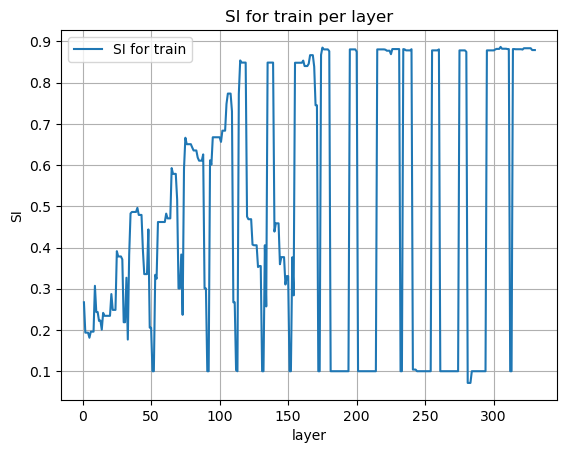

In [20]:
plot_results([si_store.cpu()], ['SI for train'], 'SI for train per layer', 'layer', 'SI')

# Evaluating for Test Set

In [21]:
list_of_output_dicts_for_test = []
total_labels = torch.zeros((0), device=device)
verbose_efficientnet.eval()
for data, labels in si_test_loader:
    with torch.inference_mode():
        _ = verbose_efficientnet(data.to(device))
        list_of_output_dicts_for_test.append(verbose_efficientnet.outputs_dict)
        total_labels = torch.cat((total_labels, labels.to(device)))

In [22]:
torch.cuda.empty_cache()
gc.collect()

3997

In [23]:
si_store = torch.zeros(len(verbose_efficientnet.order), device=device)
for i in range(len(verbose_efficientnet.order)):
    layer_si = si_of_layer(list_of_output_dicts_for_test, total_labels, i, verbose_efficientnet, device)
    si_store[i] = layer_si
    print(i)

part 1 time: 0.0001475811004638672
part 2 time: 0.0008056163787841797
part 3 (si) time: 0.0015811920166015625
part 4 (del) time: 0.0015995502471923828
0
part 1 time: 2.8133392333984375e-05
part 2 time: 0.000225067138671875
part 3 (si) time: 0.0006475448608398438
part 4 (del) time: 0.0006639957427978516
1
part 1 time: 2.384185791015625e-05
part 2 time: 0.000278472900390625
part 3 (si) time: 0.0005884170532226562
part 4 (del) time: 0.0006020069122314453
2
part 1 time: 1.71661376953125e-05
part 2 time: 0.000293731689453125
part 3 (si) time: 0.0005693435668945312
part 4 (del) time: 0.0005824565887451172
3
part 1 time: 1.6927719116210938e-05
part 2 time: 0.00019407272338867188
part 3 (si) time: 0.0004589557647705078
part 4 (del) time: 0.0004711151123046875
4
part 1 time: 1.5974044799804688e-05
part 2 time: 0.00023245811462402344
part 3 (si) time: 0.0005099773406982422
part 4 (del) time: 0.0005223751068115234
5
part 1 time: 1.621246337890625e-05
part 2 time: 0.00020456314086914062
part 3 (si

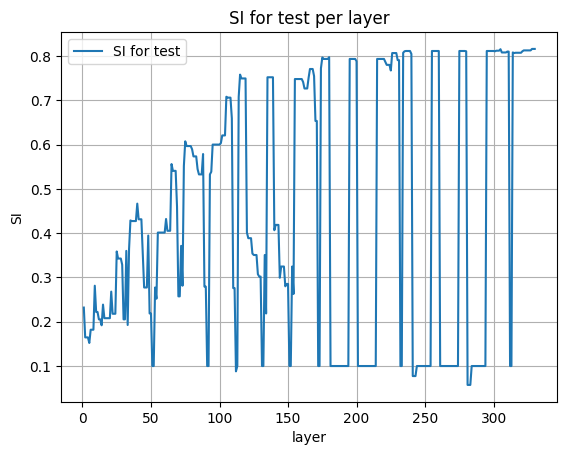

In [24]:
plot_results([si_store.cpu()], ['SI for test'], 'SI for test per layer', 'layer', 'SI')

## investigation on layers and corresponding SI (just for test)

In [24]:
num = 50
print('si:', si_store[num])
print(verbose_efficientnet.idx_to_name[verbose_efficientnet.order[num]])

si: tensor(0.1000, device='cuda:0')
features.2.1.block.2.fc2


In [26]:
for name, item in efficientnet_b0.named_modules():
    if name == 'features.2.1.block.2.fc1':
        print(item)

Conv2d(144, 6, kernel_size=(1, 1), stride=(1, 1))


In [27]:
for name, item in efficientnet_b0.named_modules():
    if name == 'features.2.1.block.2.activation':
        print(item)

SiLU(inplace=True)


In [28]:
for name, item in efficientnet_b0.named_modules():
    if name == 'features.2.1.block.2.fc2':
        print(item)

Conv2d(6, 144, kernel_size=(1, 1), stride=(1, 1))


In [29]:
for name, item in efficientnet_b0.named_modules():
    if name == 'features.2.1.block.2.scale_activation':
        print(item)

Sigmoid()


In [34]:
for i in range(160, 200): 
    num = 50
    print('layer:', i,'si:', si_store[i].item())
    l_name = verbose_efficientnet.idx_to_name[verbose_efficientnet.order[i]]
    print(l_name)
    for name, item in efficientnet_b0.named_modules():
        if name == l_name:
            print(item,'\n')

layer: 160 si: 0.8535999655723572
features.5.0.block.0.0
Conv2d(80, 480, kernel_size=(1, 1), stride=(1, 1), bias=False) 

layer: 161 si: 0.840399980545044
features.5.0.block.0.1
BatchNorm2d(480, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 

layer: 162 si: 0.840399980545044
features.5.0.block.0.2
SiLU(inplace=True) 

layer: 163 si: 0.840399980545044
features.5.0.block.0
Conv2dNormActivation(
  (0): Conv2d(80, 480, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(480, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
) 

layer: 164 si: 0.8459999561309814
features.5.0.block.1.0
Conv2d(480, 480, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=480, bias=False) 

layer: 165 si: 0.8667999505996704
features.5.0.block.1.1
BatchNorm2d(480, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) 

layer: 166 si: 0.8667999505996704
features.5.0.block.1.2
SiLU(inplace=True) 

layer: 167 si: 0.866799950599

In [30]:
num = 51
verbose_efficientnet.outputs_dict[verbose_efficientnet.order[num]][0]

tensor([[[0.5000]],

        [[0.5000]],

        [[0.5000]],

        [[0.5060]],

        [[0.5000]],

        [[0.5000]],

        [[0.4991]],

        [[0.4999]],

        [[0.5058]],

        [[0.5000]],

        [[0.5000]],

        [[0.4964]],

        [[0.5016]],

        [[0.5000]],

        [[0.5000]],

        [[0.5000]],

        [[0.5000]],

        [[0.5000]],

        [[0.5005]],

        [[0.5000]],

        [[0.5030]],

        [[0.5000]],

        [[0.5000]],

        [[0.5000]],

        [[0.5000]],

        [[0.5000]],

        [[0.4937]],

        [[0.5001]],

        [[0.5000]],

        [[0.5000]],

        [[0.4926]],

        [[0.5000]],

        [[0.5079]],

        [[0.5109]],

        [[0.5031]],

        [[0.4939]],

        [[0.4952]],

        [[0.5000]],

        [[0.5000]],

        [[0.5000]],

        [[0.5000]],

        [[0.5000]],

        [[0.5000]],

        [[0.5044]],

        [[0.5000]],

        [[0.5031]],

        [[0.5042]],

        [[0.5

In [31]:
num = 54
print('si:', si_store[num])
print(verbose_efficientnet.idx_to_name[verbose_efficientnet.order[num]])

si: tensor(0.4013, device='cuda:0')
features.2.1.block.3.1


In [32]:
for name, item in efficientnet_b0.named_modules():
    print(name)


features
features.0
features.0.0
features.0.1
features.0.2
features.1
features.1.0
features.1.0.block
features.1.0.block.0
features.1.0.block.0.0
features.1.0.block.0.1
features.1.0.block.0.2
features.1.0.block.1
features.1.0.block.1.avgpool
features.1.0.block.1.fc1
features.1.0.block.1.fc2
features.1.0.block.1.activation
features.1.0.block.1.scale_activation
features.1.0.block.2
features.1.0.block.2.0
features.1.0.block.2.1
features.1.0.stochastic_depth
features.2
features.2.0
features.2.0.block
features.2.0.block.0
features.2.0.block.0.0
features.2.0.block.0.1
features.2.0.block.0.2
features.2.0.block.1
features.2.0.block.1.0
features.2.0.block.1.1
features.2.0.block.1.2
features.2.0.block.2
features.2.0.block.2.avgpool
features.2.0.block.2.fc1
features.2.0.block.2.fc2
features.2.0.block.2.activation
features.2.0.block.2.scale_activation
features.2.0.block.3
features.2.0.block.3.0
features.2.0.block.3.1
features.2.0.stochastic_depth
features.2.1
features.2.1.block
features.2.1.block

In [33]:
torch.__version__

'1.12.1+cu116'

In [34]:
# python_version = 11